# NBA PLAYERS PERFORMANCE PREDICTION

## 1. Import Dataset and Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mp

In [ ]:
data=pd.read_csv('nba_data.csv')
data

,gameid,date,type,playerid,player,team,home,away,MIN,PTS,...,DREB,REB,AST,STL,BLK,TOV,PF,+/-,win,season
0,29600001,1996-11-01,regular,677,Eric Williams,BOS,BOS,CHI,25,14,...,1,3,1,0,0,1,4,1,0,1997
1,29600001,1996-11-01,regular,442,Pervis Ellison,BOS,BOS,CHI,31,7,...,6,10,0,3,2,3,5,-8,0,1997
2,29600001,1996-11-01,regular,783,Frank Brickowski,BOS,BOS,CHI,19,3,...,1,2,4,2,0,5,5,-7,0,1997
3,29600001,1996-11-01,regular,344,Dana Barros,BOS,BOS,CHI,38,24,...,1,1,6,1,0,3,2,-4,0,1997
4,29600001,1996-11-01,regular,133,David Wesley,BOS,BOS,CHI,41,19,...,2,3,6,2,0,1,4,-22,0,1997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787526,42500405,2026-06-13,playoff,1642868,Carter Bryant,SAS,SAS,NYK,6,0,...,2,2,0,0,0,1,0,2,0,2026
787527,42500405,2026-06-13,playoff,1628436,Luke Kornet,SAS,SAS,NYK,10,0,...,1,2,0,0,0,1,2,-3,0,2026
787528,42500405,2026-06-13,playoff,1630540,Miles McBride,NYK,SAS,NYK,13,0,...,0,0,1,0,0,0,1,3,1,2026
787529,42500405,2026-06-13,playoff,1630631,Jose Alvarado,NYK,SAS,NYK,11,0,...,1,1,0,0,0,0,1,-11,1,2026


## 2. Data Pre-processing

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787531 entries, 0 to 787530
Data columns (total 30 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   gameid    787531 non-null  int64  
 1   date      787531 non-null  object 
 2   type      787531 non-null  object 
 3   playerid  787531 non-null  int64  
 4   player    787531 non-null  object 
 5   team      787531 non-null  object 
 6   home      787531 non-null  object 
 7   away      787531 non-null  object 
 8   MIN       787531 non-null  int64  
 9   PTS       787531 non-null  int64  
 10  FGM       787531 non-null  int64  
 11  FGA       787531 non-null  int64  
 12  FG%       787531 non-null  float64
 13  3PM       787531 non-null  int64  
 14  3PA       787531 non-null  int64  
 15  3P%       787531 non-null  float64
 16  FTM       787531 non-null  int64  
 17  FTA       787531 non-null  int64  
 18  FT%       787531 non-null  float64
 19  OREB      787531 non-null  int64  
 20  DREB

In [ ]:
data.describe()

,gameid,playerid,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,...,DREB,REB,AST,STL,BLK,TOV,PF,+/-,win,season
count,7.875310e+05,7.875310e+05,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,...,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000,787531.000000
mean,2.357505e+07,4.120765e+05,23.346859,9.869497,3.664293,8.044412,41.727827,0.785103,2.199144,19.909298,...,3.043569,4.120797,2.182949,0.740517,0.473579,1.332245,2.022521,-0.000281,0.500156,2011.903124
std,5.711037e+06,6.417945e+05,11.502284,8.270197,3.105297,5.839919,25.189957,1.246815,2.629262,28.828387,...,2.708304,3.535083,2.533368,0.991152,0.885338,1.416513,1.517253,10.715384,0.500000,8.598727
min,2.000000e+07,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,1997.000000
25%,2.080006e+07,1.736000e+03,15.000000,3.000000,1.000000,3.000000,27.300000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-7.000000,0.000000,2005.000000
50%,2.150120e+07,2.007450e+05,24.000000,8.000000,3.000000,7.000000,42.900000,0.000000,1.000000,0.000000,...,2.000000,3.000000,1.000000,0.000000,0.000000,1.000000,2.000000,0.000000,1.000000,2012.000000
75%,2.230096e+07,2.035260e+05,33.000000,15.000000,5.000000,12.000000,57.100000,1.000000,4.000000,37.500000,...,4.000000,6.000000,3.000000,1.000000,1.000000,2.000000,3.000000,6.000000,1.000000,2019.000000
max,5.250021e+07,1.643257e+06,65.000000,83.000000,28.000000,50.000000,100.000000,14.000000,24.000000,100.000000,...,25.000000,33.000000,25.000000,11.000000,13.000000,14.000000,7.000000,57.000000,1.000000,2026.000000


## 3. Filter only the last 5 seasons

In [ ]:
data_last5 = data[(data['season'] >= 2022) & (data['season'] <= 2026)]
data_last5.head()

,gameid,date,type,playerid,player,team,home,away,MIN,PTS,...,DREB,REB,AST,STL,BLK,TOV,PF,+/-,win,season
646599,22100001,2021-10-19,regular,201142,Kevin Durant,BKN,MIL,BKN,30,32,...,11,11,4,0,2,1,2,-20,0,2022
646600,22100001,2021-10-19,regular,1627761,DeAndre' Bembry,BKN,MIL,BKN,4,0,...,0,0,0,0,0,0,0,-9,0,2022
646601,22100001,2021-10-19,regular,200794,Paul Millsap,BKN,MIL,BKN,5,0,...,2,3,0,0,1,1,0,-1,0,2022
646602,22100001,2021-10-19,regular,203925,Joe Harris,BKN,MIL,BKN,31,9,...,2,2,2,0,0,2,1,0,0,2022
646603,22100001,2021-10-19,regular,1630560,Cam Thomas,BKN,MIL,BKN,4,2,...,0,0,0,0,0,1,0,-9,0,2022


In [ ]:
data_last5.tail()

,gameid,date,type,playerid,player,team,home,away,MIN,PTS,...,DREB,REB,AST,STL,BLK,TOV,PF,+/-,win,season
787526,42500405,2026-06-13,playoff,1642868,Carter Bryant,SAS,SAS,NYK,6,0,...,2,2,0,0,0,1,0,2,0,2026
787527,42500405,2026-06-13,playoff,1628436,Luke Kornet,SAS,SAS,NYK,10,0,...,1,2,0,0,0,1,2,-3,0,2026
787528,42500405,2026-06-13,playoff,1630540,Miles McBride,NYK,SAS,NYK,13,0,...,0,0,1,0,0,0,1,3,1,2026
787529,42500405,2026-06-13,playoff,1630631,Jose Alvarado,NYK,SAS,NYK,11,0,...,1,1,0,0,0,0,1,-11,1,2026
787530,42500405,2026-06-13,playoff,1631110,Jeremy Sochan,NYK,SAS,NYK,0,0,...,0,0,0,0,0,0,0,1,1,2026


## 4. Data Cleaning

In [ ]:
data_last5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140932 entries, 646599 to 787530
Data columns (total 30 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   gameid    140932 non-null  int64  
 1   date      140932 non-null  object 
 2   type      140932 non-null  object 
 3   playerid  140932 non-null  int64  
 4   player    140932 non-null  object 
 5   team      140932 non-null  object 
 6   home      140932 non-null  object 
 7   away      140932 non-null  object 
 8   MIN       140932 non-null  int64  
 9   PTS       140932 non-null  int64  
 10  FGM       140932 non-null  int64  
 11  FGA       140932 non-null  int64  
 12  FG%       140932 non-null  float64
 13  3PM       140932 non-null  int64  
 14  3PA       140932 non-null  int64  
 15  3P%       140932 non-null  float64
 16  FTM       140932 non-null  int64  
 17  FTA       140932 non-null  int64  
 18  FT%       140932 non-null  float64
 19  OREB      140932 non-null  int64  
 20  DREB

In [ ]:
data_last5.isna().sum()

,0
gameid,0
date,0
type,0
playerid,0
player,0
team,0
home,0
away,0
MIN,0
PTS,0


In [ ]:
data_last5.duplicated().sum()

np.int64(0)

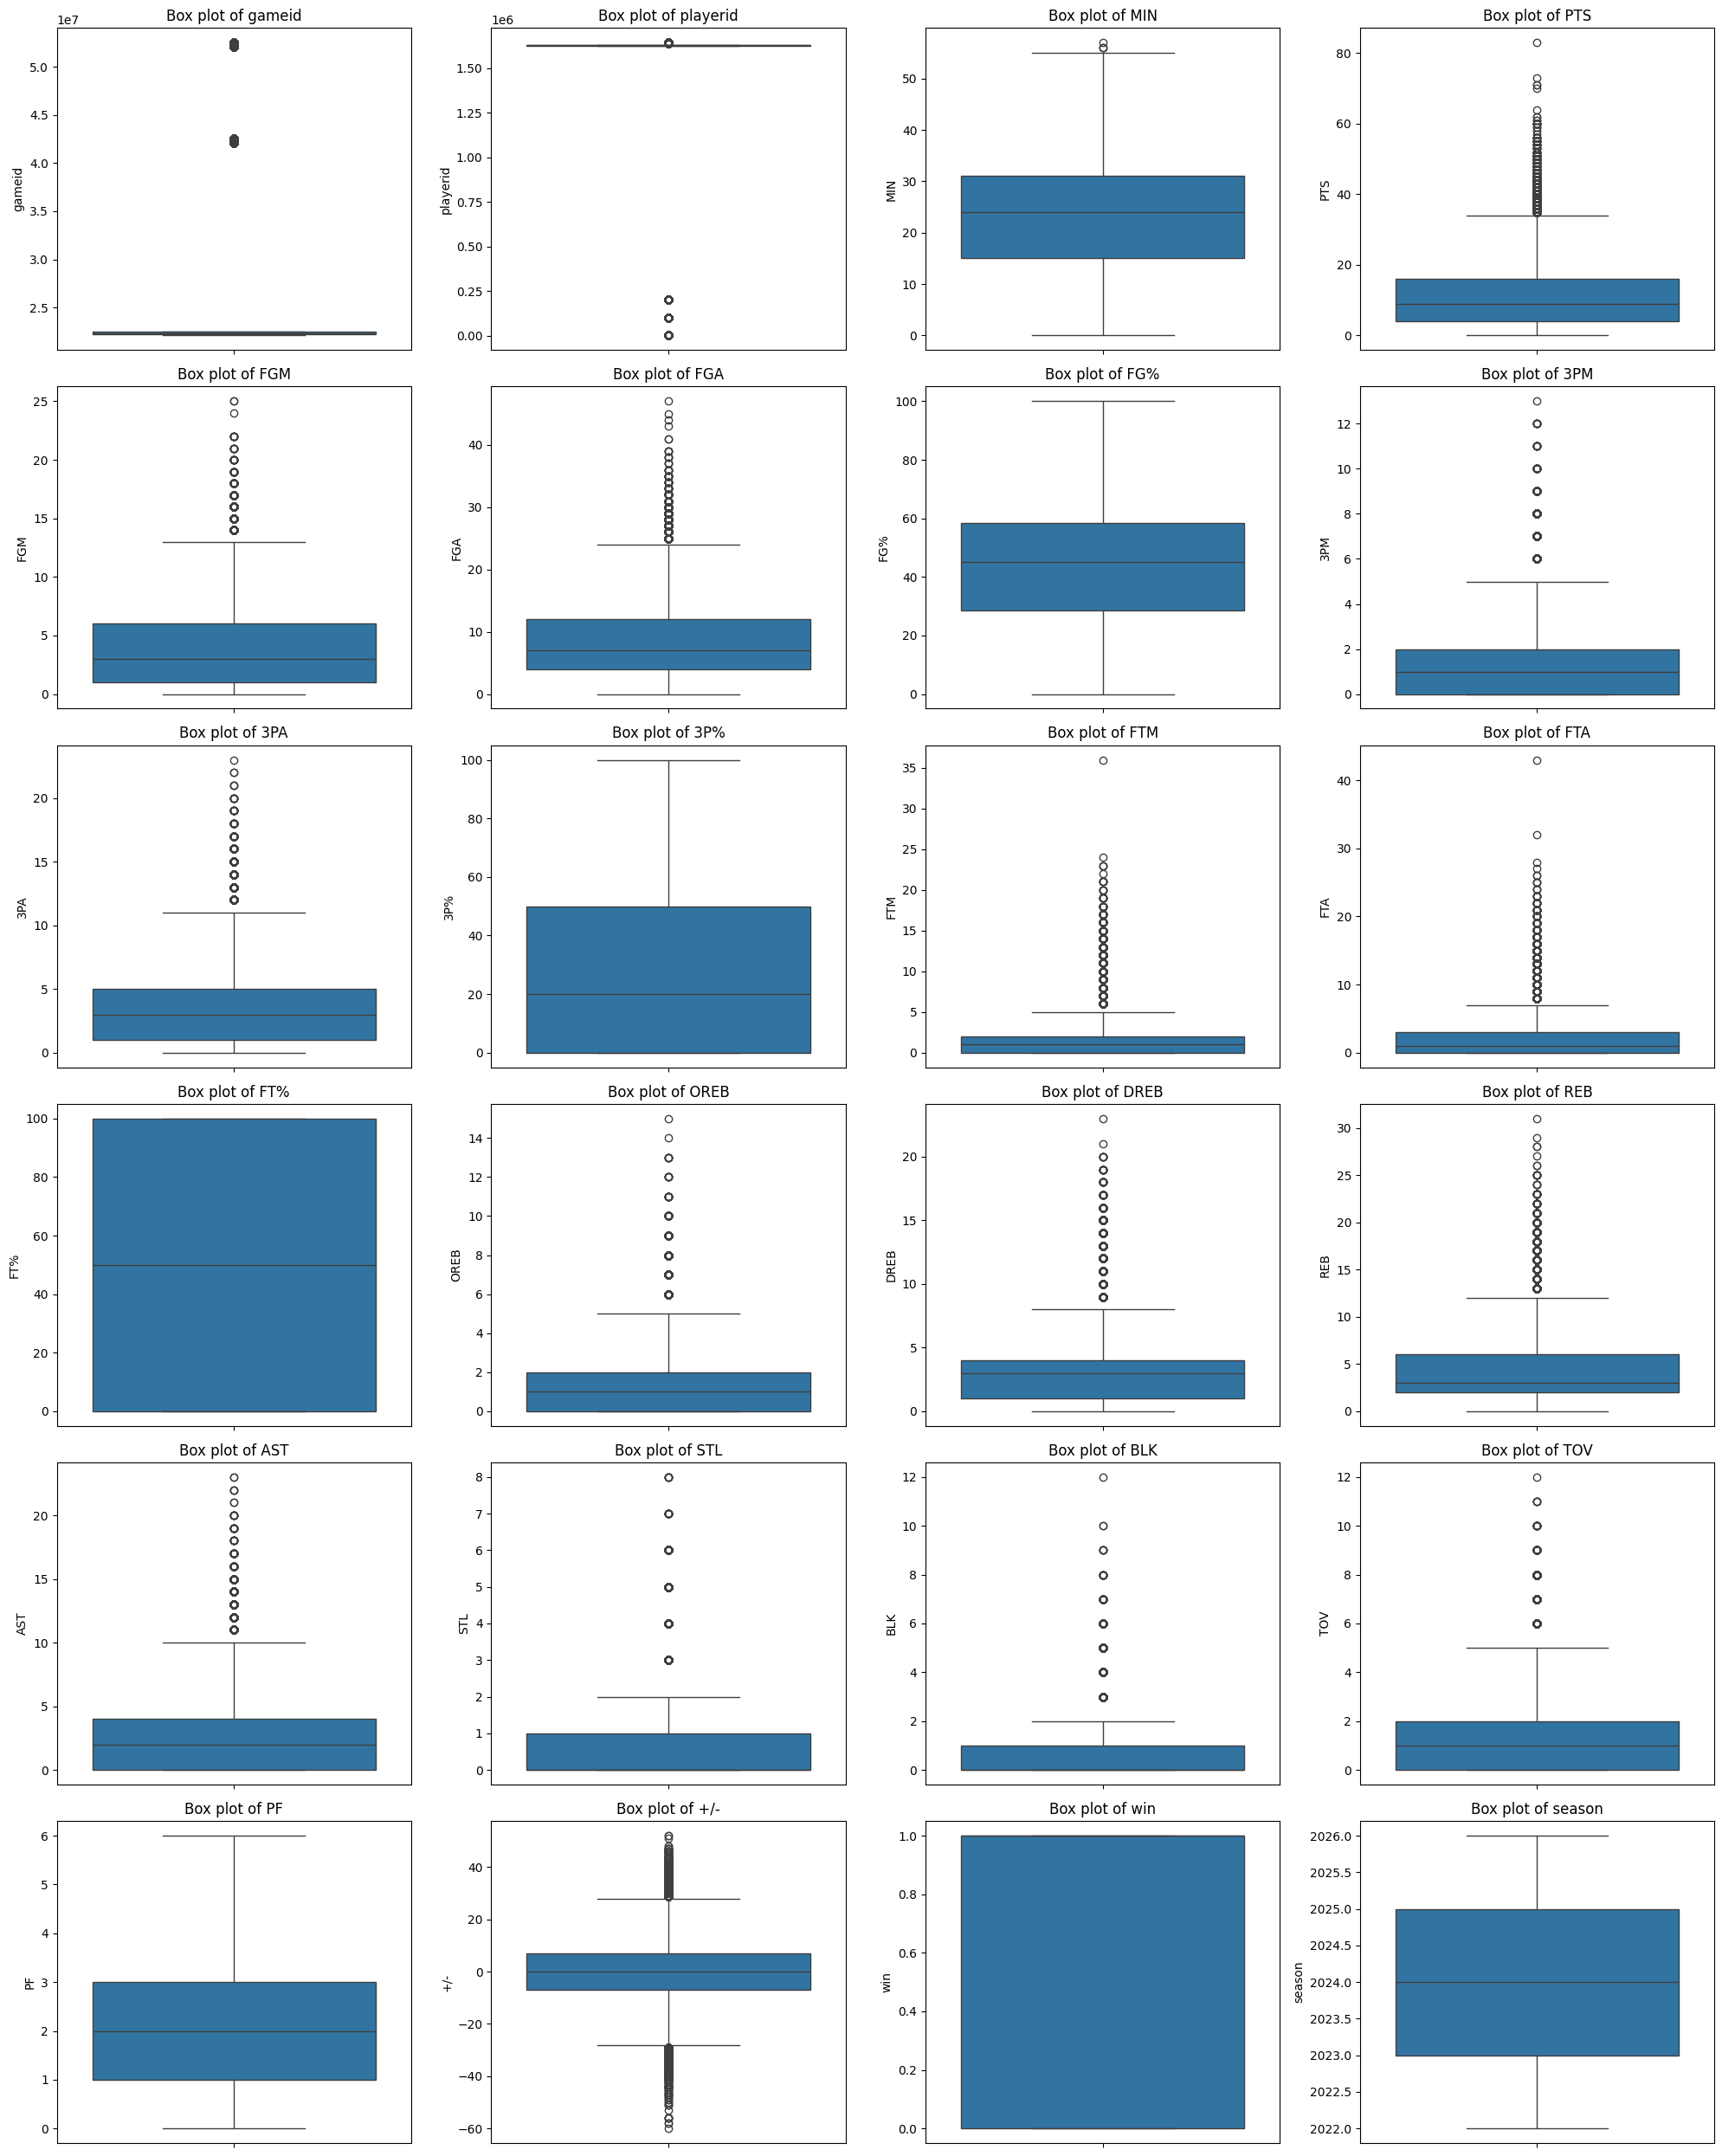

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = data_last5.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1) # Adjust subplot grid as needed based on number of numerical columns
    sns.boxplot(y=data_last5[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
columns_to_clean = ['FTA', 'FTM', 'BLK']

for col in columns_to_clean:
    Q1 = data_last5[col].quantile(0.25)
    Q3 = data_last5[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data_last5 = data_last5[(data_last5[col] >= lower_bound) & (data_last5[col] <= upper_bound)]

print(f"DataFrame shape after outlier removal: {data_last5.shape}")
data_last5.head()

DataFrame shape after outlier removal: (125960, 30)


,gameid,date,type,playerid,player,team,home,away,MIN,PTS,...,DREB,REB,AST,STL,BLK,TOV,PF,+/-,win,season
646599,22100001,2021-10-19,regular,201142,Kevin Durant,BKN,MIL,BKN,30,32,...,11,11,4,0,2,1,2,-20,0,2022
646600,22100001,2021-10-19,regular,1627761,DeAndre' Bembry,BKN,MIL,BKN,4,0,...,0,0,0,0,0,0,0,-9,0,2022
646601,22100001,2021-10-19,regular,200794,Paul Millsap,BKN,MIL,BKN,5,0,...,2,3,0,0,1,1,0,-1,0,2022
646602,22100001,2021-10-19,regular,203925,Joe Harris,BKN,MIL,BKN,31,9,...,2,2,2,0,0,2,1,0,0,2022
646603,22100001,2021-10-19,regular,1630560,Cam Thomas,BKN,MIL,BKN,4,2,...,0,0,0,0,0,1,0,-9,0,2022


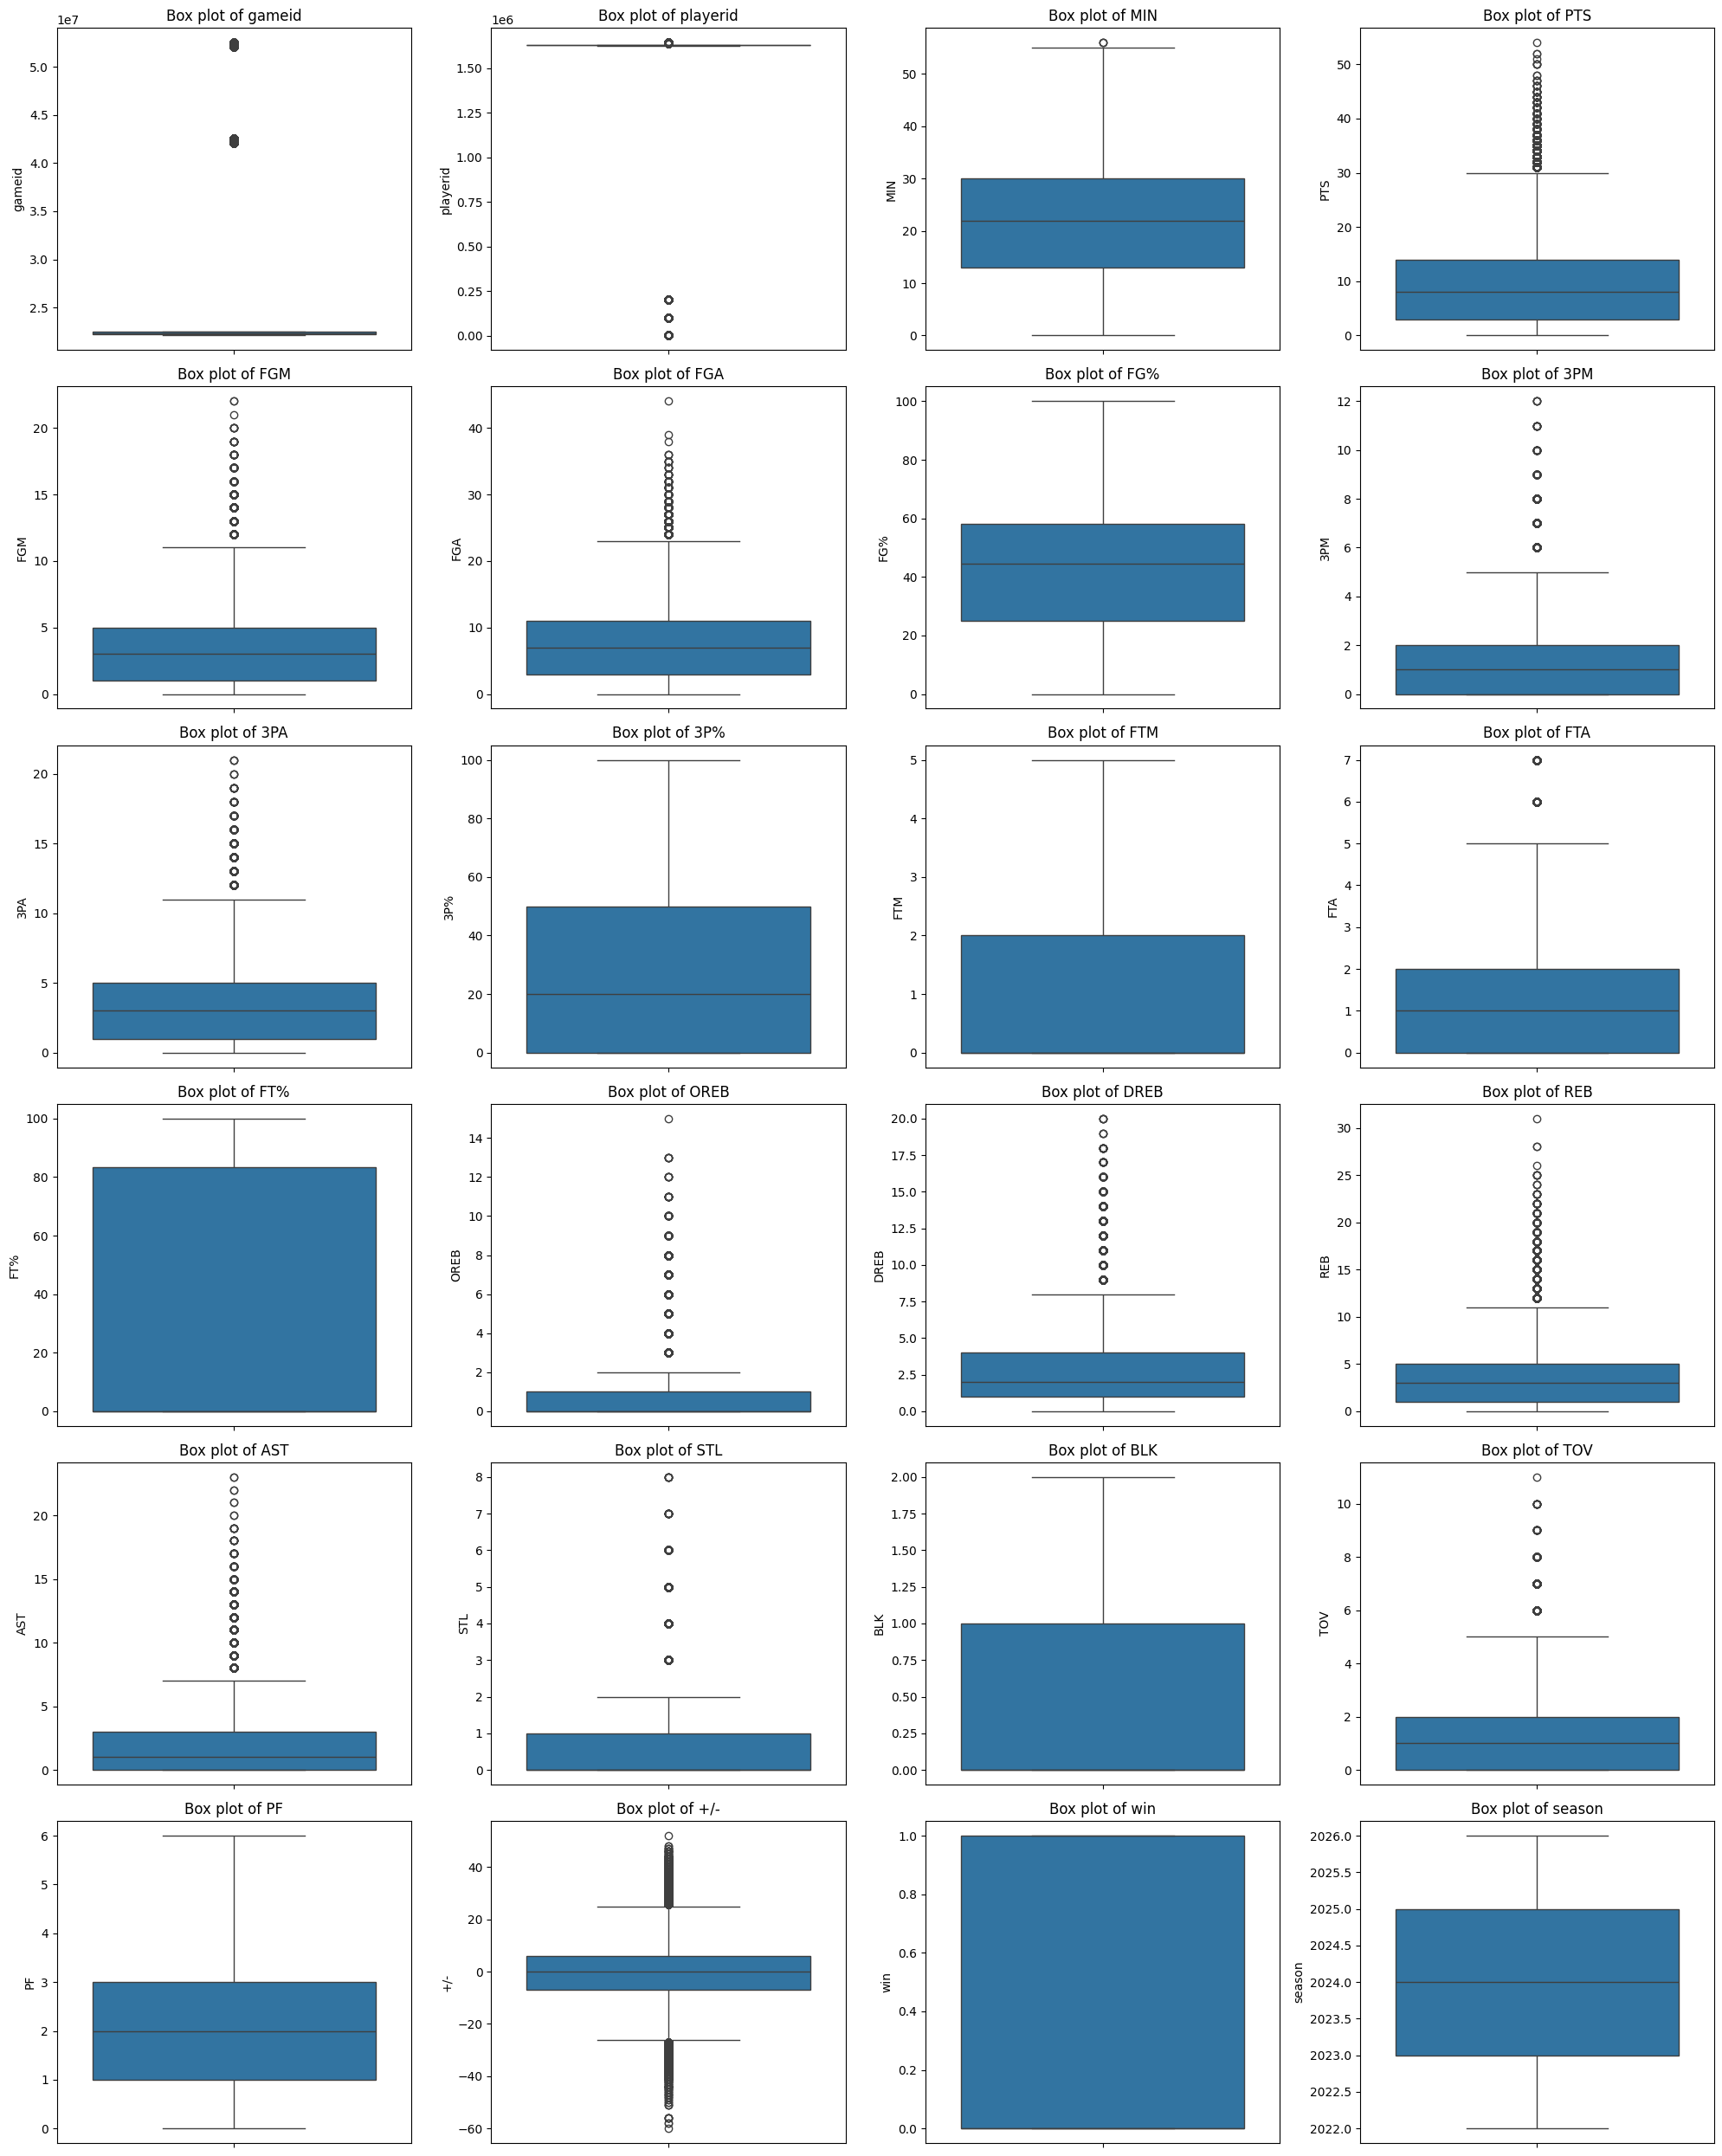

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = data_last5.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1) # Adjust subplot grid as needed based on number of numerical columns
    sns.boxplot(y=data_last5[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
data_last5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125960 entries, 646599 to 787530
Data columns (total 30 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   gameid    125960 non-null  int64  
 1   date      125960 non-null  object 
 2   type      125960 non-null  object 
 3   playerid  125960 non-null  int64  
 4   player    125960 non-null  object 
 5   team      125960 non-null  object 
 6   home      125960 non-null  object 
 7   away      125960 non-null  object 
 8   MIN       125960 non-null  int64  
 9   PTS       125960 non-null  int64  
 10  FGM       125960 non-null  int64  
 11  FGA       125960 non-null  int64  
 12  FG%       125960 non-null  float64
 13  3PM       125960 non-null  int64  
 14  3PA       125960 non-null  int64  
 15  3P%       125960 non-null  float64
 16  FTM       125960 non-null  int64  
 17  FTA       125960 non-null  int64  
 18  FT%       125960 non-null  float64
 19  OREB      125960 non-null  int64  
 20  DREB

In [ ]:
nba=data_last5
nba.tail()

,gameid,date,type,playerid,player,team,home,away,MIN,PTS,...,DREB,REB,AST,STL,BLK,TOV,PF,+/-,win,season
787526,42500405,2026-06-13,playoff,1642868,Carter Bryant,SAS,SAS,NYK,6,0,...,2,2,0,0,0,1,0,2,0,2026
787527,42500405,2026-06-13,playoff,1628436,Luke Kornet,SAS,SAS,NYK,10,0,...,1,2,0,0,0,1,2,-3,0,2026
787528,42500405,2026-06-13,playoff,1630540,Miles McBride,NYK,SAS,NYK,13,0,...,0,0,1,0,0,0,1,3,1,2026
787529,42500405,2026-06-13,playoff,1630631,Jose Alvarado,NYK,SAS,NYK,11,0,...,1,1,0,0,0,0,1,-11,1,2026
787530,42500405,2026-06-13,playoff,1631110,Jeremy Sochan,NYK,SAS,NYK,0,0,...,0,0,0,0,0,0,0,1,1,2026


## 5. Feature Engineering

Generate aggregated metrics for each players per season

In [ ]:
# 1. Filter raw game logs for 2022 through 2026 (and active games)
nba_filtered = nba[
    (nba['season'] >= 2022) &
    (nba['season'] <= 2026) &
    (nba['MIN'] > 0)
].copy()

In [ ]:
# 2. Aggregate game logs to season level (1 row per player per season)
player_profiles = nba_filtered.groupby(['playerid', 'player','season']).agg(
    GP=('PTS', 'count'),
    MPG=('MIN', 'mean'),
    PPG=('PTS', 'mean'),
    RPG=('REB', 'mean'),
    APG=('AST', 'mean'),
    SPG=('STL', 'mean'),
    BPG=('BLK', 'mean'),
    TOPG=('TOV', 'mean'),
    Plus_Minus=('+/-', 'mean'),
    Total_FGM=('FGM', 'sum'),
    Total_FGA=('FGA', 'sum'),
    Total_3PM=('3PM', 'sum'),
    Total_3PA=('3PA', 'sum'),
    Total_FTM=('FTM', 'sum'),
    Total_FTA=('FTA', 'sum'),
    PTS_Std=('PTS', 'std'),
    Max_PTS=('PTS', 'max')
).reset_index()

In [ ]:
# 3. Calculate true overall shooting efficiency features
player_profiles['FG%'] = (player_profiles['Total_FGM'] / player_profiles['Total_FGA']).fillna(0)
player_profiles['3P%'] = (player_profiles['Total_3PM'] / player_profiles['Total_3PA']).fillna(0)
player_profiles['FT%'] = (player_profiles['Total_FTM'] / player_profiles['Total_FTA']).fillna(0)

In [ ]:
# 4. Filter out extreme low-sample noise (e.g., players with < 15 total games)
nba_data = player_profiles[player_profiles['GP'] >= 15].copy()

In [ ]:
nba_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2330 entries, 1 to 2862
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   playerid    2330 non-null   int64  
 1   player      2330 non-null   object 
 2   season      2330 non-null   int64  
 3   GP          2330 non-null   int64  
 4   MPG         2330 non-null   float64
 5   PPG         2330 non-null   float64
 6   RPG         2330 non-null   float64
 7   APG         2330 non-null   float64
 8   SPG         2330 non-null   float64
 9   BPG         2330 non-null   float64
 10  TOPG        2330 non-null   float64
 11  Plus_Minus  2330 non-null   float64
 12  Total_FGM   2330 non-null   int64  
 13  Total_FGA   2330 non-null   int64  
 14  Total_3PM   2330 non-null   int64  
 15  Total_3PA   2330 non-null   int64  
 16  Total_FTM   2330 non-null   int64  
 17  Total_FTA   2330 non-null   int64  
 18  PTS_Std     2330 non-null   float64
 19  Max_PTS     2330 non-null   int6

In [ ]:
# Determine the most frequent team for each player from the filtered game logs
player_team_counts = nba_filtered.groupby(['playerid', 'team']).size().reset_index(name='count')
most_frequent_team = player_team_counts.loc[player_team_counts.groupby('playerid')['count'].idxmax()]
player_team_mapping = most_frequent_team[['playerid', 'team']]

# Before merging, remove any existing 'team', 'team_x', or 'team_y' columns from nba_data
# This ensures a clean merge and prevents errors if the cell is run multiple times.
existing_team_cols = [col for col in nba_data.columns if 'team' in col]
if existing_team_cols:
    nba_data = nba_data.drop(columns=existing_team_cols)

# Merge the team information into nba_data
nba_data = pd.merge(nba_data, player_team_mapping, on='playerid', how='left')

nba_data.head(30)

,playerid,player,season,GP,MPG,PPG,RPG,APG,SPG,BPG,...,Total_3PM,Total_3PA,Total_FTM,Total_FTA,PTS_Std,Max_PTS,FG%,3P%,FT%,team
0,2544,LeBron James,2022,33,36.606061,28.636364,7.484848,6.090909,1.393939,0.878788,...,92,247,99,133,6.927383,39,0.533994,0.372470,0.744361,LAL
1,2544,LeBron James,2023,47,35.680851,26.106383,8.659574,6.787234,0.936170,0.659574,...,107,332,144,197,6.757392,46,0.490452,0.322289,0.730964,LAL
2,2544,LeBron James,2024,51,35.098039,24.078431,6.901961,7.960784,1.176471,0.490196,...,104,267,152,212,6.012797,40,0.529989,0.389513,0.716981,LAL
3,2544,LeBron James,2025,52,34.884615,22.384615,7.538462,8.038462,1.057692,0.461538,...,98,284,134,182,6.624831,39,0.491561,0.345070,0.736264,LAL
4,2544,LeBron James,2026,48,33.958333,20.020833,5.729167,7.041667,1.291667,0.479167,...,65,187,134,191,6.051163,36,0.517663,0.347594,0.701571,LAL
5,2546,Carmelo Anthony,2022,64,25.953125,12.968750,4.156250,0.906250,0.625000,0.625000,...,136,364,114,138,6.151445,29,0.438066,0.373626,0.826087,LAL
6,2730,Dwight Howard,2022,56,15.589286,5.517857,5.660714,0.517857,0.553571,0.553571,...,8,12,75,118,4.377592,21,0.614130,0.666667,0.635593,LAL
7,2738,Andre Iguodala,2022,37,17.081081,3.540541,2.756757,3.297297,0.729730,0.540541,...,18,77,15,21,3.602427,12,0.382812,0.233766,0.714286,GSW
8,2772,Trevor Ariza,2022,24,19.208333,4.000000,3.416667,1.125000,0.541667,0.250000,...,20,74,10,18,3.336231,12,0.333333,0.270270,0.555556,LAL
9,101108,Chris Paul,2022,69,32.913043,14.536232,4.231884,10.057971,1.840580,0.304348,...,70,213,137,166,5.952211,33,0.508301,0.328638,0.825301,PHX


In [ ]:
nba_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2330 entries, 0 to 2329
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   playerid    2330 non-null   int64  
 1   player      2330 non-null   object 
 2   season      2330 non-null   int64  
 3   GP          2330 non-null   int64  
 4   MPG         2330 non-null   float64
 5   PPG         2330 non-null   float64
 6   RPG         2330 non-null   float64
 7   APG         2330 non-null   float64
 8   SPG         2330 non-null   float64
 9   BPG         2330 non-null   float64
 10  TOPG        2330 non-null   float64
 11  Plus_Minus  2330 non-null   float64
 12  Total_FGM   2330 non-null   int64  
 13  Total_FGA   2330 non-null   int64  
 14  Total_3PM   2330 non-null   int64  
 15  Total_3PA   2330 non-null   int64  
 16  Total_FTM   2330 non-null   int64  
 17  Total_FTA   2330 non-null   int64  
 18  PTS_Std     2330 non-null   float64
 19  Max_PTS     2330 non-null  

In [ ]:
y = nba_data['PPG']
X = nba_data.drop(columns=['PPG', 'playerid', 'player'], errors='ignore')

print("Target variable (y) head:")
print(y.head())
print("\nFeatures (X) head:")
print(X.head())

Target variable (y) head:
0    28.636364
1    26.106383
2    24.078431
3    22.384615
4    20.020833
Name: PPG, dtype: float64

Features (X) head:
   season  GP        MPG       RPG       APG       SPG       BPG      TOPG  \
0    2022  33  36.606061  7.484848  6.090909  1.393939  0.878788  3.545455   
1    2023  47  35.680851  8.659574  6.787234  0.936170  0.659574  3.212766   
2    2024  51  35.098039  6.901961  7.960784  1.176471  0.490196  3.450980   
3    2025  52  34.884615  7.538462  8.038462  1.057692  0.461538  3.615385   
4    2026  48  33.958333  5.729167  7.041667  1.291667  0.479167  2.916667   

   Plus_Minus  Total_FGM  ...  Total_3PM  Total_3PA  Total_FTM  Total_FTA  \
0   -3.575758        377  ...         92        247         99        133   
1    2.276596        488  ...        107        332        144        197   
2    1.274510        486  ...        104        267        152        212   
3   -1.961538        466  ...         98        284        134        182   

Encoding categorical column

In [ ]:
X = pd.get_dummies(X, columns=['team'], drop_first=True)

print("Features (X) head after one-hot encoding:")
print(X.head())

Features (X) head after one-hot encoding:
   season  GP        MPG       RPG       APG       SPG       BPG      TOPG  \
0    2022  33  36.606061  7.484848  6.090909  1.393939  0.878788  3.545455   
1    2023  47  35.680851  8.659574  6.787234  0.936170  0.659574  3.212766   
2    2024  51  35.098039  6.901961  7.960784  1.176471  0.490196  3.450980   
3    2025  52  34.884615  7.538462  8.038462  1.057692  0.461538  3.615385   
4    2026  48  33.958333  5.729167  7.041667  1.291667  0.479167  2.916667   

   Plus_Minus  Total_FGM  ...  team_OKC  team_ORL  team_PHI  team_PHX  \
0   -3.575758        377  ...     False     False     False     False   
1    2.276596        488  ...     False     False     False     False   
2    1.274510        486  ...     False     False     False     False   
3   -1.961538        466  ...     False     False     False     False   
4    2.229167        381  ...     False     False     False     False   

   team_POR  team_SAC  team_SAS  team_TOR  team_UT

In [ ]:
X

,season,GP,MPG,RPG,APG,SPG,BPG,TOPG,Plus_Minus,Total_FGM,...,team_OKC,team_ORL,team_PHI,team_PHX,team_POR,team_SAC,team_SAS,team_TOR,team_UTA,team_WAS
0,2022,33,36.606061,7.484848,6.090909,1.393939,0.878788,3.545455,-3.575758,377,...,False,False,False,False,False,False,False,False,False,False
1,2023,47,35.680851,8.659574,6.787234,0.936170,0.659574,3.212766,2.276596,488,...,False,False,False,False,False,False,False,False,False,False
2,2024,51,35.098039,6.901961,7.960784,1.176471,0.490196,3.450980,1.274510,486,...,False,False,False,False,False,False,False,False,False,False
3,2025,52,34.884615,7.538462,8.038462,1.057692,0.461538,3.615385,-1.961538,466,...,False,False,False,False,False,False,False,False,False,False
4,2026,48,33.958333,5.729167,7.041667,1.291667,0.479167,2.916667,2.229167,381,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2325,2026,40,8.725000,1.950000,0.550000,0.275000,0.125000,0.250000,-2.575000,27,...,True,False,False,False,False,False,False,False,False,False
2326,2026,38,12.947368,1.552632,1.052632,0.684211,0.105263,0.710526,-2.631579,60,...,False,False,False,False,False,False,False,False,False,False
2327,2026,15,32.866667,3.800000,4.133333,2.266667,0.333333,1.466667,-9.933333,50,...,False,False,False,False,False,False,False,False,True,False
2328,2026,17,15.882353,1.588235,0.941176,0.176471,0.000000,0.823529,-0.117647,43,...,False,False,False,False,False,False,False,False,False,False


## 6. Feature Selection

L1 Regularization and Univariate selection

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1. Evaluate Features against continuous Target using F-Regression
# Works on BOTH numerical features and 0/1 One-Hot Encoded team columns
f_scores, p_values = f_regression(X, y)

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values(by='F_Score', ascending=False)

print("Top Features by F-Score:")
print(feature_importance_df.head(10))

Top Features by F-Score:
      Feature      F_Score        P_Value
2         MPG  9111.086995   0.000000e+00
16    Max_PTS  7145.741379   0.000000e+00
7        TOPG  5668.330714   0.000000e+00
9   Total_FGM  4775.779069   0.000000e+00
10  Total_FGA  4361.064090   0.000000e+00
15    PTS_Std  3874.350152   0.000000e+00
13  Total_FTM  3731.847152   0.000000e+00
14  Total_FTA  3110.068286   0.000000e+00
4         APG  2701.454041   0.000000e+00
5         SPG  1448.948547  6.340555e-247


In [ ]:
# 2. Automated Feature Selection using Lasso (L1 Penalty)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)
selected_features = X.columns[lasso.coef_ != 0]

In [ ]:
print(f"\nLasso selected {len(selected_features)} out of {X.shape[1]} total features:")
print(selected_features.tolist())


Lasso selected 26 out of 49 total features:
['season', 'GP', 'MPG', 'APG', 'SPG', 'TOPG', 'Plus_Minus', 'Total_FGM', 'Total_3PM', 'Total_FTM', 'PTS_Std', 'Max_PTS', 'FG%', '3P%', 'FT%', 'team_BKN', 'team_CLE', 'team_DAL', 'team_LAL', 'team_MIA', 'team_MIL', 'team_NYK', 'team_OKC', 'team_PHX', 'team_SAC', 'team_SAS']


In [ ]:
selected_features

Index(['season', 'GP', 'MPG', 'APG', 'SPG', 'TOPG', 'Plus_Minus', 'Total_FGM',
       'Total_3PM', 'Total_FTM', 'PTS_Std', 'Max_PTS', 'FG%', '3P%', 'FT%',
       'team_BKN', 'team_CLE', 'team_DAL', 'team_LAL', 'team_MIA', 'team_MIL',
       'team_NYK', 'team_OKC', 'team_PHX', 'team_SAC', 'team_SAS'],
      dtype='object')

## 7. Data Partitioning

In [ ]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler

# 1. Separate Features (X), Target (y), and Group Identifier
# Use the already processed X (with Lasso-selected features and one-hot encoding)
# and the target y (PPG) that were previously defined.
# The 'selected_features' Index should be used to filter X if it's not already filtered.
# Assuming X currently holds all features (including one-hot encoded) before feature selection was applied to create selected_features
X_filtered = X[selected_features]
groups = nba_data['playerid']   # Prevents data leakage across seasons for the same player

# 2. Perform Group Train/Test Split (80% Train, 20% Test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_filtered, y, groups))

X_train, X_test = X_filtered.iloc[train_idx], X_filtered.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Save corresponding metadata for post-evaluation display
# This assumes player and season columns are in nba_data, which they are.
train_meta = nba_data.iloc[train_idx][['player', 'season']]
test_meta = nba_data.iloc[test_idx][['player', 'season']]

# 3. Fit Feature Scaler ON TRAIN ONLY (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-1.41085364, -0.97124994,  1.82236286, ..., -0.20327891,
        -0.18416528, -0.19756628],
       [-0.70393069, -0.26962076,  1.71584068, ..., -0.20327891,
        -0.18416528, -0.19756628],
       [ 0.00299227, -0.06915529,  1.64873978, ..., -0.20327891,
        -0.18416528, -0.19756628],
       ...,
       [ 1.41683818, -1.87334459,  1.39183508, ..., -0.20327891,
        -0.18416528, -0.19756628],
       [ 1.41683818, -1.77311185, -0.56362057, ..., -0.20327891,
        -0.18416528, -0.19756628],
       [ 1.41683818, -1.82322822, -0.08234754, ..., -0.20327891,
        -0.18416528, -0.19756628]])

In [ ]:
X_test_scaled

array([[-1.41085364,  0.18142656, -0.59736229, ..., -0.20327891,
        -0.18416528, -0.19756628],
       [-1.41085364, -0.47008624,  0.12733516, ..., -0.20327891,
        -0.18416528, -0.19756628],
       [-1.41085364,  0.48212478,  1.33104978, ..., -0.20327891,
        -0.18416528, -0.19756628],
       ...,
       [ 1.41683818,  0.53224115,  0.01827965, ..., -0.20327891,
        -0.18416528, -0.19756628],
       [ 1.41683818, -0.62043535, -1.38766836, ..., -0.20327891,
        -0.18416528, -0.19756628],
       [ 1.41683818, -0.72066809, -0.90153425, ..., -0.20327891,
        -0.18416528, -0.19756628]])

## 8. Model Training

Linear Regression

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fit standard Linear Regression independently
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
lr_preds = lr_model.predict(X_test_scaled)

In [ ]:
# Calculate metrics
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

In [ ]:
print(f"--- LINEAR REGRESSION ---")
print(f"MAE:  {lr_mae:.2f} PPG")
print(f"RMSE: {lr_rmse:.2f} PPG")
print(f"R²:   {lr_r2:.3f}")

--- LINEAR REGRESSION ---
MAE:  0.91 PPG
RMSE: 1.18 PPG
R²:   0.950


Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Fit Random Forest independently
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=6, min_samples_leaf=5, random_state=42)

In [ ]:
# Predict on test set
rf_preds = rf_model.predict(X_test_scaled)

In [ ]:
# Calculate metrics
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

In [ ]:
print(f"--- RANDOM FOREST ---")
print(f"MAE:  {rf_mae:.2f} PPG")
print(f"RMSE: {rf_rmse:.2f} PPG")
print(f"R²:   {rf_r2:.3f}")

--- RANDOM FOREST ---
MAE:  1.00 PPG
RMSE: 1.41 PPG
R²:   0.929


XGBoost Regression

In [ ]:
from xgboost import XGBRegressor

# Fit XGBoost independently
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    reg_lambda=1.0,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predict on test set
xgb_preds = xgb_model.predict(X_test_scaled)

In [ ]:
# Calculate metrics
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

In [ ]:
print(f"--- XGBOOST REGRESSOR ---")
print(f"MAE:  {xgb_mae:.2f} PPG")
print(f"RMSE: {xgb_rmse:.2f} PPG")
print(f"R²:   {xgb_r2:.3f}")

--- XGBOOST REGRESSOR ---
MAE:  0.87 PPG
RMSE: 1.19 PPG
R²:   0.950


Comparing All Model Evaluations

In [ ]:
# Assemble comparison matrix with standard Linear Regression
model_comparison = pd.DataFrame([
    {'Model': 'Linear Regression', 'MAE': round(lr_mae, 2), 'RMSE': round(lr_rmse, 2), 'R²': round(lr_r2, 3)},
    {'Model': 'Random Forest', 'MAE': round(rf_mae, 2), 'RMSE': round(rf_rmse, 2), 'R²': round(rf_r2, 3)},
    {'Model': 'XGBoost', 'MAE': round(xgb_mae, 2), 'RMSE': round(xgb_rmse, 2), 'R²': round(xgb_r2, 3)}
]).sort_values(by='MAE')

print("\n--- FINAL EVALUATION METRICS ---")
print(model_comparison.to_string(index=False))


--- FINAL EVALUATION METRICS ---
            Model  MAE  RMSE    R²
          XGBoost 0.87  1.19 0.950
Linear Regression 0.91  1.18 0.950
    Random Forest 1.00  1.41 0.929


9. Sample of Predicted vs Actual output

In [ ]:
# Assemble evaluation table using test metadata
eval_sample = test_meta.copy()
eval_sample['Actual PPG'] = y_test.values
eval_sample['Predicted PPG'] = lr_preds
eval_sample['xPTS (Diff)'] = eval_sample['Actual PPG'] - eval_sample['Predicted PPG']

# Round metrics to standard NBA 1-decimal display
eval_sample[['Actual PPG', 'Predicted PPG', 'xPTS (Diff)']] = (
    eval_sample[['Actual PPG', 'Predicted PPG', 'xPTS (Diff)']].round(1)
)

# Display 10 random sample player-seasons
print(eval_sample.sample(10, random_state=42).to_string(index=False))

          player  season  Actual PPG  Predicted PPG  xPTS (Diff)
   Nathan Knight    2022         3.8            4.5         -0.7
   Kyle Anderson    2023         9.4           10.6         -1.2
  Bryce McGowens    2024         5.1            4.1          0.9
    Desmond Bane    2022        18.1           18.3         -0.2
    Kevin Pangos    2022         1.6            1.6          0.1
     Moses Moody    2026        11.6           11.9         -0.3
    Drew Eubanks    2026         5.2            5.3         -0.1
     Noah Vonleh    2023         1.1            2.8         -1.8
Brooks Barnhizer    2026         1.7            2.0         -0.3
Craig Porter Jr.    2026         3.9            2.9          0.9


10. Save Model

In [ ]:
import joblib

# Export model artifacts for Streamlit loading
joblib.dump(lr_model, 'xppg_model.joblib')
joblib.dump(scaler, 'xppg_scaler.joblib')
joblib.dump(selected_features, 'xppg_features.joblib')

# Save benchmark dataset for player lookup
nba_data.to_csv('nba_player_seasons_processed.csv', index=False)
print("Model artifacts and benchmark dataset saved successfully!")

Model artifacts and benchmark dataset saved successfully!
